In [1]:
import asyncio, json, os
import websockets
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import geodatasets
import tqdm as notebook_tqdm
import contextily as cx
import requests
import sys

In [2]:
# load the ports from ports.csv
ports_df = pd.read_csv('data/Ports.csv')
choke_points_df = pd.read_csv('data/PortWatch_Chokepoints_database.csv')
combined_df = pd.concat([ports_df, choke_points_df], ignore_index=True)

In [3]:
combined_df.head(5)

,X,Y,portid,portname,country,ISO3,fullname,lat,lon,pageid,ObjectId
0,1.514731e+07,4.254924e+06,port1325,Tsuruga,Japan,JPN,"Tsuruga, Japan",35.667194,136.070611,3b1f40eb8acd452ab6229331302891fe,1
1,1.099633e+07,1.931654e+05,port1198,Sibolga,Indonesia,IDN,"Sibolga, Indonesia",1.734969,98.781715,4d00b008b4be4068bf8a19d7da6e8cf6,2
2,1.206306e+07,2.465269e+06,port339,Fangcheng,China,CHN,"Fangcheng, China",21.614205,108.364339,266042b244cf452a89f4a2de14f3da2f,3
3,1.460658e+07,4.021402e+06,port1335,Ube,Japan,JPN,"Ube, Japan",33.944875,131.213184,f3f6725ef00e4d3f8f9c93c45258667e,4
4,1.874177e+07,-5.875428e+06,port153,Bluff Harbor,New Zealand,NZL,"Bluff Harbor, New Zealand",-46.590130,168.360216,894ab5e5a18e48b6922c023196f74c8f,5


In [4]:
# for each port in the combined_df, add a new column called bounding box that contains the bounding box of the port in the format (min_lat, min_lon, max_lat, max_lon) within 15km
combined_df['bounding_box'] = None  
for index, row in combined_df.iterrows():
    lat = row['lat']
    lon = row['lon']
    min_lat = lat - 0.135
    max_lat = lat + 0.135
    min_lon = lon - 0.135
    max_lon = lon + 0.135
    combined_df.at[index, 'bounding_box'] = (min_lat, min_lon, max_lat, max_lon)

In [5]:
#drop some columns from the combined_df that are not needed
combined_df = combined_df.drop(columns=['X', 'Y', 'ISO3', 'fullname'])

In [6]:
combined_df.head(5)

,portid,portname,country,lat,lon,pageid,ObjectId,bounding_box
0,port1325,Tsuruga,Japan,35.667194,136.070611,3b1f40eb8acd452ab6229331302891fe,1,"(35.53219379, 135.9356107, 35.80219379, 136.20..."
1,port1198,Sibolga,Indonesia,1.734969,98.781715,4d00b008b4be4068bf8a19d7da6e8cf6,2,"(1.599969159, 98.64671534, 1.869969159, 98.916..."
2,port339,Fangcheng,China,21.614205,108.364339,266042b244cf452a89f4a2de14f3da2f,3,"(21.47920534, 108.22933929999999, 21.749205340..."
3,port1335,Ube,Japan,33.944875,131.213184,f3f6725ef00e4d3f8f9c93c45258667e,4,"(33.80987467, 131.0781838, 34.079874669999995,..."
4,port153,Bluff Harbor,New Zealand,-46.590130,168.360216,894ab5e5a18e48b6922c023196f74c8f,5,"(-46.725129949999996, 168.22521600000002, -46...."


In [7]:
# 1. Setup port and extract metadata fields from combined_df
target_port_name = "Hong Kong"  # Change to your port
port_row = combined_df[combined_df["portname"] == target_port_name].iloc[0]

min_lat, min_lon, max_lat, max_lon = port_row["bounding_box"]

# Extract the requested port identifiers and details
p_id = port_row.get("portid", port_row.get("id", None))
p_name = port_row.get("portname", target_port_name)
p_country = port_row.get("country", None)
p_pageid = port_row.get("pageid", None)

API_KEY = os.getenv("AISSTREAM_API_KEY")
STREAM_DURATION_SECONDS = 600 

async def stream_static_data(duration):
    data_list = []
    
    try:
        async with websockets.connect(
            "wss://stream.aisstream.io/v0/stream",
            compression="deflate",
        ) as ws:
            
            # Send subscription request for ShipStaticData ONLY
            await ws.send(json.dumps({
                "APIKey": API_KEY,
                "BoundingBoxes": [[[min_lat, min_lon], [max_lat, max_lon]]],
                "FilterMessageTypes": ["ShipStaticData"]
            }))
            
            print(f"Stream opened for {p_name} ({p_country}). Waiting {duration} seconds for static data...")

            async def receive_messages():
                async for payload in ws:
                    msg = json.loads(payload)
                    
                    if msg.get("MessageType") == "ShipStaticData":
                        meta = msg.get("MetaData", {})
                        report = msg.get("Message", {}).get("ShipStaticData", {})
                        
                        # Flatten dictionaries and attach port metadata fields directly to each row
                        row_data = {
                            **meta, 
                            **report,
                            "portid": p_id,
                            "portname": p_name,
                            "country": p_country,
                            "pageid": p_pageid
                        }
                        data_list.append(row_data)
                        
                        ship_name = meta.get("ShipName", "Unknown").strip()
                        print(f"Caught static data for: {ship_name}")

            # Enforce the time limit
            await asyncio.wait_for(receive_messages(), timeout=duration)
            
    except asyncio.TimeoutError:
        print("\nTime limit reached. Closing stream.")
    except Exception as e:
        print(f"An error occurred: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    return df

# Await the function and store the result
static_df = await stream_static_data(STREAM_DURATION_SECONDS)
display(static_df.head())

Stream opened for Hong Kong (Hong Kong SAR). Waiting 600 seconds for static data...
Caught static data for: GUANGNA 628
Caught static data for: RABAUL CHIEF
Caught static data for: NORTHERN STAR
Caught static data for: SIU FAI 7
Caught static data for: PAK HOI 70
Caught static data for: ASIAN LUNA
Caught static data for: HUIXIANG668
Caught static data for: SHENNAN2858
Caught static data for: RONGXIANG7
Caught static data for: XIN MING ZHU VIII
Caught static data for: HAIBANGDA33
Caught static data for: GOLDEN DRAGON 138
Caught static data for: SCT SHEKOU
Caught static data for: BARCELONA MAERSK
Caught static data for: SHENYANG
Caught static data for: SHOPPES FOUR SEASONS
Caught static data for: THE VENETIAN
Caught static data for: BO SHI YUN 558
Caught static data for: MSC MAGNITUDE VII
Caught static data for: HAI QIN
Caught static data for: TONG WEI
Caught static data for: MINGYANG628
Caught static data for: ZIM BANGKOK
Caught static data for: GOLDEN DRAGON 338
Caught static data for:

,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,Name,RepeatIndicator,Spare,Type,UserID,Valid,portid,portname,country,pageid
0,413837481,413837481,GUANGNA 628,22.29985,114.16176,2026-09-11 03:45:22.376107537 +0000 UTC,0,,,"{'A': 70, 'B': 19, 'C': 8, 'D': 10}",...,GUANGNA 628,0,False,70,413837481,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
1,477629900,477629900,RABAUL CHIEF,22.33497,114.11657,2026-09-11 03:45:30.455735763 +0000 UTC,2,VRSL5,HKHKG,"{'A': 165, 'B': 21, 'C': 13, 'D': 19}",...,RABAUL CHIEF,0,False,74,477629900,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
2,477995431,477995431,NORTHERN STAR,22.29338,114.16858,2026-09-11 03:45:31.407478588 +0000 UTC,1,VRS4788,,"{'A': 5, 'B': 28, 'C': 4, 'D': 4}",...,NORTHERN STAR,0,False,60,477995431,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
3,477996731,477996731,SIU FAI 7,22.31355,114.20012,2026-09-11 03:45:44.920619136 +0000 UTC,2,VRS6030,,"{'A': 14, 'B': 10, 'C': 5, 'D': 5}",...,SIU FAI 7,0,False,90,477996731,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
4,477996969,477996969,PAK HOI 70,22.31112,114.15889,2026-09-11 03:45:48.529801009 +0000 UTC,2,VRS6252,A,"{'A': 7, 'B': 14, 'C': 6, 'D': 1}",...,PAK HOI 70,0,False,90,477996969,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807


In [8]:
static_df.head(5)

,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,Name,RepeatIndicator,Spare,Type,UserID,Valid,portid,portname,country,pageid
0,413837481,413837481,GUANGNA 628,22.29985,114.16176,2026-09-11 03:45:22.376107537 +0000 UTC,0,,,"{'A': 70, 'B': 19, 'C': 8, 'D': 10}",...,GUANGNA 628,0,False,70,413837481,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
1,477629900,477629900,RABAUL CHIEF,22.33497,114.11657,2026-09-11 03:45:30.455735763 +0000 UTC,2,VRSL5,HKHKG,"{'A': 165, 'B': 21, 'C': 13, 'D': 19}",...,RABAUL CHIEF,0,False,74,477629900,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
2,477995431,477995431,NORTHERN STAR,22.29338,114.16858,2026-09-11 03:45:31.407478588 +0000 UTC,1,VRS4788,,"{'A': 5, 'B': 28, 'C': 4, 'D': 4}",...,NORTHERN STAR,0,False,60,477995431,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
3,477996731,477996731,SIU FAI 7,22.31355,114.20012,2026-09-11 03:45:44.920619136 +0000 UTC,2,VRS6030,,"{'A': 14, 'B': 10, 'C': 5, 'D': 5}",...,SIU FAI 7,0,False,90,477996731,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
4,477996969,477996969,PAK HOI 70,22.31112,114.15889,2026-09-11 03:45:48.529801009 +0000 UTC,2,VRS6252,A,"{'A': 7, 'B': 14, 'C': 6, 'D': 1}",...,PAK HOI 70,0,False,90,477996969,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807


In [9]:
# find the unique destinations in the static_df and count how many ships are going to each destination
destination_counts = static_df['Destination'].value_counts()
destination_counts

Destination
                        28
HONG KONG                9
HONG KONG                7
HONGKONG                 6
HK                       5
HKHKG                    4
HK                       4
HONGKONG                 2
EGSUZ>>>HKHKG            2
XYANGGANG                2
CENTRAL CC               2
XIANGGANG                2
NAN SHA                  2
XHQ                      2
CNTAO                    2
CENTRAL-CC               2
NANSHA                   2
HKHKG > CNXHK            2
                         1
HK-MAC                   1
A                        1
XIANGGANG                1
HK<->MAC                 1
YAN TIAN                 1
HKG                      1
NAN SHA                  1
JZ-HK 068.10             1
CNHKG                    1
HK HKG                   1
HONGKONG WQIA            1
HONGKONG-CN              1
KWUN TONG-NORTHPOINT     1
SAASHAN                  1
7                        1
HK HKG                   1
CHEUNG@CHAU              1
HK.100.9.L      

In [10]:
# filter the dataframe to only indicate destination as AMSTERDAM
#destination_df = static_df[static_df['Destination'].str.upper() == 'AMSTERDAM']
destination_df = static_df # only when destinations are of mixed variables but indicating same thing ie hk_hkg or hkg or hong kong

In [11]:
# find the ship types and count occurrences of each type
ship_types = destination_df['Type'].unique()
for ship_type in ship_types:
    count = destination_df[destination_df['Type'] == ship_type].shape[0]
    print(f"Ship type: {ship_type}, Count: {count}")

Ship type: 70, Count: 35
Ship type: 74, Count: 5
Ship type: 60, Count: 11
Ship type: 90, Count: 6
Ship type: 30, Count: 2
Ship type: 40, Count: 18
Ship type: 80, Count: 9
Ship type: 52, Count: 3
Ship type: 71, Count: 5
Ship type: 0, Count: 3
Ship type: 49, Count: 1
Ship type: 31, Count: 4
Ship type: 91, Count: 1
Ship type: 37, Count: 2
Ship type: 81, Count: 1
Ship type: 89, Count: 1
Ship type: 50, Count: 1
Ship type: 72, Count: 2


In [12]:
# Comprehensive ITU AIS ship type dictionary (0 to 99)
itu_ship_types = {
    0: ("Not available", "Unknown"),
    **{i: ("Reserved for future use", "Unknown") for i in range(1, 20)},
    20: ("Wing in ground (WIG)", "General"),
    21: ("Wing in ground (WIG)", "Hazardous category A"),
    22: ("Wing in ground (WIG)", "Hazardous category B"),
    23: ("Wing in ground (WIG)", "Hazardous category C"),
    24: ("Wing in ground (WIG)", "Hazardous category D"),
    **{i: ("Wing in ground (WIG)", "Reserved") for i in range(25, 30)},
    30: ("Fishing", "Catch / General"),
    31: ("Towing", "Towing service"),
    32: ("Towing (length >200m or breadth >25m)", "Towing service"),
    33: ("Dredging or underwater ops", "Dredged material / Spoil"),
    34: ("Diving ops", "Equipment / Special"),
    35: ("Military ops", "Defense / Special"),
    36: ("Sailing", "Recreational"),
    37: ("Pleasure Craft", "Recreational"),
    38: ("Reserved", "Unknown"),
    39: ("Reserved", "Unknown"),
    40: ("High speed craft (HSC)", "All ships of this type"),
    41: ("High speed craft (HSC)", "Hazardous category A"),
    42: ("High speed craft (HSC)", "Hazardous category B"),
    43: ("High speed craft (HSC)", "Hazardous category C"),
    44: ("High speed craft (HSC)", "Hazardous category D"),
    **{i: ("High speed craft (HSC)", "Reserved") for i in range(45, 50)},
    50: ("Pilot Vessel", "Pilot service"),
    51: ("Search and Rescue vessel", "Emergency service"),
    52: ("Tug", "Towing service"),
    53: ("Port Tender", "Port operations"),
    54: ("Anti-pollution equipment", "Environmental service"),
    55: ("Law Enforcement", "Official / Police"),
    56: ("Spare - Local Vessel", "Local service"),
    57: ("Spare - Local Vessel", "Local service"),
    58: ("Medical Transport", "Medical service"),
    59: ("Noncombatant ship", "Special service"),
    60: ("Passenger", "All ships of this type"),
    61: ("Passenger", "Hazardous category A"),
    62: ("Passenger", "Hazardous category B"),
    63: ("Passenger", "Hazardous category C"),
    64: ("Passenger", "Hazardous category D"),
    **{i: ("Passenger", "Reserved") for i in range(65, 69)},
    69: ("Passenger", "No additional information"),
    70: ("Cargo", "All ships of this type"),
    71: ("Cargo", "Hazardous category A"),
    72: ("Cargo", "Hazardous category B"),
    73: ("Cargo", "Hazardous category C"),
    74: ("Cargo", "Hazardous category D"),
    **{i: ("Cargo", "Reserved") for i in range(75, 79)},
    79: ("Cargo", "No additional information"),
    80: ("Tanker", "All ships of this type"),
    81: ("Tanker", "Hazardous category A"),
    82: ("Tanker", "Hazardous category B"),
    83: ("Tanker", "Hazardous category C"),
    84: ("Tanker", "Hazardous category D"),
    **{i: ("Tanker", "Reserved") for i in range(85, 89)},
    89: ("Tanker", "No additional information"),
    90: ("Other Type", "All ships of this type"),
    91: ("Other Type", "Hazardous category A"),
    92: ("Other Type", "Hazardous category B"),
    93: ("Other Type", "Hazardous category C"),
    94: ("Other Type", "Hazardous category D"),
    **{i: ("Other Type", "Reserved") for i in range(95, 99)},
    99: ("Other Type", "No additional information")
}

def map_ship_type(code):
    if pd.isna(code):
        return "Unknown", "Unknown"
    try:
        code_int = int(code)
        return itu_ship_types.get(code_int, (f"Unknown ({code_int})", "Unknown"))
    except ValueError:
        return "Unknown", "Unknown"

# Apply mapping to your DataFrame
if 'destination_df' in locals() and not destination_df.empty and 'Type' in destination_df.columns:
    mapped_data = destination_df['Type'].apply(map_ship_type)
    destination_df['ShipCategory'] = [m[0] for m in mapped_data]
    destination_df['MaterialCarried'] = [m[1] for m in mapped_data]
    
    # View clean results
    display(destination_df[['ShipName', 'MMSI', 'Type', 'ShipCategory', 'MaterialCarried', 'Destination']].drop_duplicates(subset=['MMSI']).head(15))
else:
    print("destination_df is not available or missing the 'Type' column.")

,ShipName,MMSI,Type,ShipCategory,MaterialCarried,Destination
0,GUANGNA 628,413837481,70,Cargo,All ships of this type,
1,RABAUL CHIEF,477629900,74,Cargo,Hazardous category D,HKHKG
2,NORTHERN STAR,477995431,60,Passenger,All ships of this type,
3,SIU FAI 7,477996731,90,Other Type,All ships of this type,
4,PAK HOI 70,477996969,90,Other Type,All ships of this type,A
5,ASIAN LUNA,563300300,70,Cargo,All ships of this type,HONGKONG
6,HUIXIANG668,413999262,70,Cargo,All ships of this type,XYANGGANG
7,SHENNAN2858,412252858,30,Fishing,Catch / General,
8,RONGXIANG7,413271670,70,Cargo,All ships of this type,HONG KONG
9,XIN MING ZHU VIII,477997054,40,High speed craft (HSC),All ships of this type,CENTRAL CC


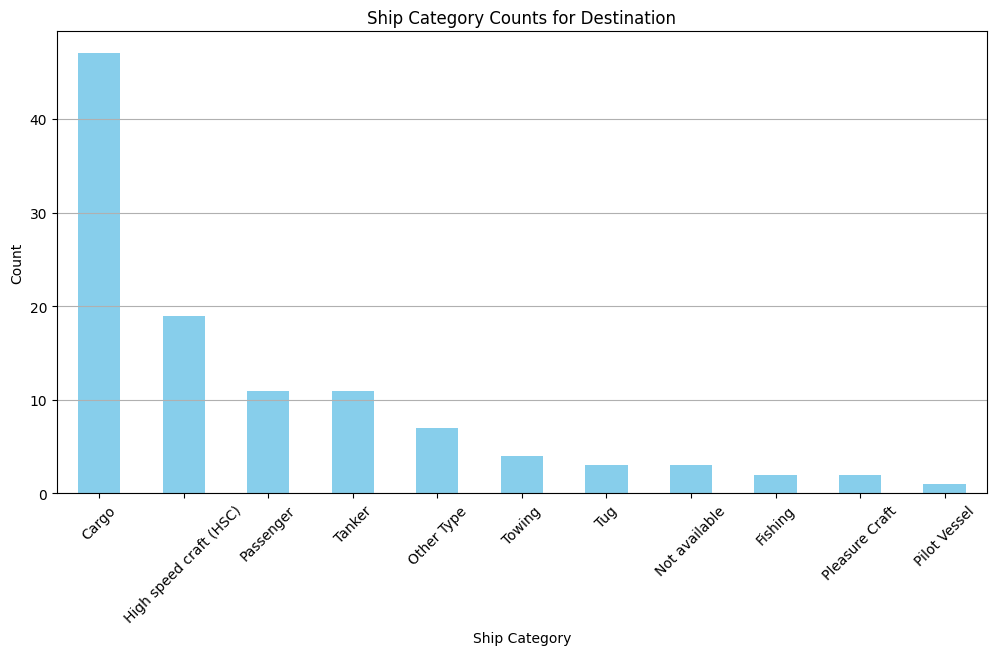

In [13]:
#visualize the ship category and count occurrences of each category in a bar chart
if 'destination_df' in locals() and not destination_df.empty and 'ShipCategory' in destination_df.columns:
    category_counts = destination_df['ShipCategory'].value_counts()
    plt.figure(figsize=(12, 6))
    category_counts.plot(kind='bar', color='skyblue')
    plt.title('Ship Category Counts for Destination')
    plt.xlabel('Ship Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
else:
    print("destination_df is not available or missing the 'ShipCategory' column.")

In [14]:
import requests
import pandas as pd

def query_daily_port_data(port_id=None):
    url = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Ports_Data/FeatureServer/0/query"
    
    where_clause = f"portid = '{port_id.lower()}'" if port_id else "1=1"
    
    params = {
        "where": where_clause,
        "outFields": "year,month,day,portid,portname,import_container,import_dry_bulk,import_general_cargo,import_roro,import_tanker",
        "maxRecordCountFactor": 5,
        "outSR": 4326,
        "f": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

if __name__ == "__main__":
    data = query_daily_port_data("port474")
    features = data.get("features", [])
    
    if features:
        shipping_df = pd.DataFrame([f["attributes"] for f in features])
        
        # Sort if year, month, day are available
        if {"year", "month", "day"}.issubset(shipping_df.columns):
            shipping_df = shipping_df.sort_values(["year", "month", "day"])
            
        print("data exists")
    else:
        print("No records found.")

data exists


In [15]:
shipping_df.head(5)

,year,month,day,portid,portname,import_container,import_dry_bulk,import_general_cargo,import_roro,import_tanker
0,2019,1,1,port474,Hong Kong,240177,35845,4514,2464,35992
1,2019,1,2,port474,Hong Kong,309051,66648,3486,0,49272
2,2019,1,3,port474,Hong Kong,444601,57405,6423,2815,45489
3,2019,1,4,port474,Hong Kong,458225,54373,1504,0,95954
4,2019,1,5,port474,Hong Kong,400019,0,21680,0,219592


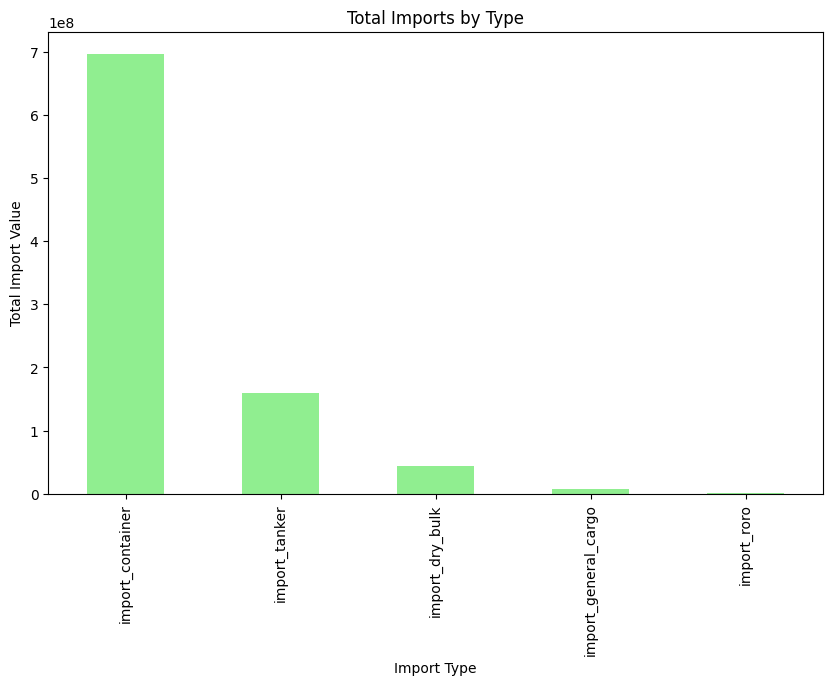

In [17]:
#visualize the import types and sort them in descending order
import_types = ['import_container', 'import_dry_bulk', 'import_general_cargo', 'import_roro', 'import_tanker']
import_sums = shipping_df[import_types].sum()
import_sums_sorted = import_sums.sort_values(ascending=False)
import_sums_sorted.plot(kind='bar', color='lightgreen', figsize=(10, 6))
plt.title('Total Imports by Type')
plt.xlabel('Import Type')
plt.ylabel('Total Import Value')
plt.show()

In [19]:
def query_port_database(port_id):
    url = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_ports_database/FeatureServer/0/query"
    
    params = {
        "where": f"portid = '{port_id.lower()}'",
        "outFields": "portid,portname,country,industry_top1,industry_top2,industry_top3",
        "returnGeometry": "false",
        "outSR": 4326,
        "f": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

if __name__ == "__main__":
    data = query_port_database("PORT474")
    features = data.get("features", [])
    
    if features:
        industry_df = pd.DataFrame([f["attributes"] for f in features])
        print("Records found")
    else:
        print("No records found.")

Records found


In [20]:
industry_df.head(5)

,portid,portname,country,industry_top1,industry_top2,industry_top3
0,port474,Hong Kong,Hong Kong SAR,Mineral Products,Vegetable Products,Prepared Foodstuffs & Beverages


In [39]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_macro_model(shipping_df, industry_df):
    """
    Trains the LightGBM macro model strictly on historical shipping trends, 
    industry profiles, and calendar features.
    """
    # 1. Preprocess and sort shipping history
    shipping_df['date'] = pd.to_datetime(shipping_df[['year', 'month', 'day']])
    shipping_df = shipping_df.sort_values(['portid', 'date']).reset_index(drop=True)
    
    # Calendar features
    shipping_df['dayofweek'] = shipping_df['date'].dt.dayofweek
    shipping_df['is_weekend'] = shipping_df['dayofweek'].isin([5, 6]).astype(int)
    shipping_df['dayofmonth'] = shipping_df['date'].dt.day
    
    import_cols = [c for c in shipping_df.columns if c.startswith('import_') and 'rolling' not in c and 'lag' not in c]
    shipping_df['total_daily_import'] = shipping_df[import_cols].sum(axis=1)
    
    # Engineer Lag and Rolling Features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        shipping_df[f'import_lag_{lag}'] = shipping_df.groupby('portid')['total_daily_import'].shift(lag)
        
    for window in [7, 14, 30]:
        shipping_df[f'import_rolling_mean_{window}'] = (
            shipping_df.groupby('portid')['total_daily_import']
            .shift(1)
            .rolling(window)
            .mean()
        )
        shipping_df[f'import_rolling_std_{window}'] = (
            shipping_df.groupby('portid')['total_daily_import']
            .shift(1)
            .rolling(window)
            .std()
        )
    
    # Merge structural industry profile
    merged_df = pd.merge(shipping_df, industry_df, on=['portid', 'portname'], how='left')
    
    # Target: Mean Daily Import over the next 7 days
    merged_df['target_next_7days_mean'] = (
        merged_df.groupby('portid')['total_daily_import']
        .rolling(7)
        .mean()
        .shift(-7)
        .reset_index(0, drop=True)
    )
    
    model_df = merged_df.dropna(subset=['target_next_7days_mean']).copy()
    
    categorical_features = ['portid', 'country', 'industry_top1', 'industry_top2', 'industry_top3']
    for col in categorical_features:
        if col in model_df.columns:
            model_df[col] = model_df[col].astype('category')
            
    exclude_cols = ['date', 'portname', 'target_next_7days_mean', 'total_daily_import', 'year', 'month', 'day']
    feature_cols = [c for c in model_df.columns if c not in exclude_cols]
    
    X = model_df[feature_cols]
    y = model_df['target_next_7days_mean']
    
    # Train using TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)
    models = []
    
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.02,
            max_depth=6,
            random_state=42
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        models.append(model)
        
    return models[-1], feature_cols, X, y, tscv

def predict_with_live_websocket(model, feature_cols, X, shipping_df, destination_df, target_portid='port474'):
    """
    Generates the baseline macro prediction for the latest available date 
    and applies the 10-minute websocket destination_df scalar correction.
    """
    # Grab the latest feature row for the target port
    latest_row = X.tail(1)
    baseline_pred = model.predict(latest_row)[0]
    
    # Process the 10-minute live websocket snapshot
    if not destination_df.empty:
        live_vessel_count = len(destination_df)
        
        # Define a baseline normal expectation for a 10-minute snapshot window
        expected_normal_vessels = 8.0 
        
        # Bounded pressure factor (clamped between 0.85 and 1.15 to avoid wild swings)
        pressure_factor = np.clip(live_vessel_count / expected_normal_vessels, 0.85, 1.15)
        
        final_forecast = baseline_pred * pressure_factor
        
        print(f"--- Live Port Forecast Adjustment ---")
        print(f"Baseline Macro Forecast (Next 7-Day Mean): {baseline_pred:,.2f}")
        print(f"10-Min Websocket Active Vessel Count: {live_vessel_count}")
        print(f"Applied Traffic Pressure Factor: {pressure_factor:.2f}")
        print(f"Final Live-Adjusted Forecast: {final_forecast:,.2f}")
        
        return final_forecast
    else:
        print(f"No websocket snapshot found. Returning baseline: {baseline_pred:,.2f}")
        return baseline_pred

# --- Execution Flow ---
# 1. Train the macro model
model, feature_cols, X, y, tscv = train_macro_model(shipping_df, industry_df)

# 2. Run inference combining historical baseline + live 10-min websocket data
final_forecast = predict_with_live_websocket(model, feature_cols, X, shipping_df, destination_df, target_portid='port474')

/Users/misango/anaconda3/envs/research_env/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/misango/anaconda3/envs/research_env/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3890
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 21
[LightGBM] [Info] Start training from score 383965.324710
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/Users/misango/anaconda3/envs/research_env/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Validation RMSE: 42,741.61
Validation MAE: 34,073.32
Validation R² Score: 0.1221


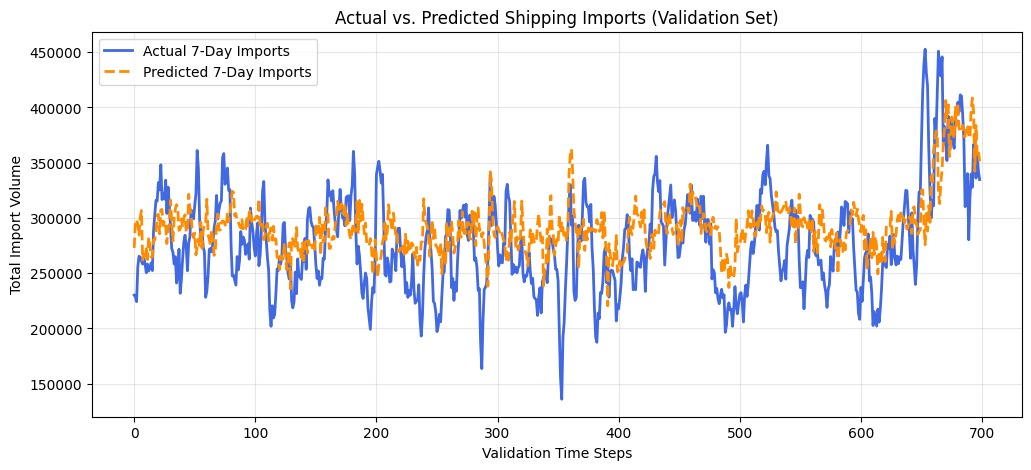

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt

# Re-initialize TimeSeriesSplit with the same splits used during training
tscv = TimeSeriesSplit(n_splits=3)

# Retrieve the validation split from the final iteration
for train_idx, val_idx in tscv.split(X):
    pass

X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

# Generate predictions using the trained model
y_pred = model.predict(X_val)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation MAE: {mae:,.2f}")
print(f"Validation R² Score: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_val.values, label='Actual 7-Day Imports', color='royalblue', linewidth=2)
plt.plot(y_pred, label='Predicted 7-Day Imports', color='darkorange', linestyle='--', linewidth=2)
plt.title('Actual vs. Predicted Shipping Imports (Validation Set)')
plt.xlabel('Validation Time Steps')
plt.ylabel('Total Import Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                   Feature  Importance
21   import_rolling_std_30         761
20  import_rolling_mean_30         581
19   import_rolling_std_14         502
18  import_rolling_mean_14         459
17    import_rolling_std_7         418
16   import_rolling_mean_7         386
8               dayofmonth         382
1         import_container         325
9             import_lag_1         268
11            import_lag_3         242


In [42]:
def predict_with_live_websocket_detailed(model, feature_cols, X, shipping_df, industry_df, destination_df, target_portid='port474'):
    """
    Generates the baseline macro prediction and breaks down the live 110-vessel 
    surge by specific vessel type and port industry profile.
    """
    # Grab the latest feature row for the target port
    latest_row = X.tail(1)
    baseline_pred = model.predict(latest_row)[0]
    
    # Extract port industry profile
    port_info = industry_df[industry_df['portid'] == target_portid]
    if not port_info.empty:
        port_name = port_info.iloc[0].get('portname', target_portid)
        industries = [
            port_info.iloc[0].get('industry_top1', 'N/A'),
            port_info.iloc[0].get('industry_top2', 'N/A'),
            port_info.iloc[0].get('industry_top3', 'N/A')
        ]
    else:
        port_name = target_portid
        industries = ['N/A', 'N/A', 'N/A']
    
    # Process the 10-minute live websocket snapshot
    if not destination_df.empty:
        live_vessel_count = len(destination_df)
        
        # Identify vessel category column dynamically
        cat_col = next((col for col in ['ShipCategory', 'Type', 'category', 'ship_type'] if col in destination_df.columns), None)
        if cat_col:
            vessel_breakdown = destination_df[cat_col].value_counts().to_dict()
        else:
            vessel_breakdown = {'Unknown Type': live_vessel_count}
        
        # Define baseline expectation and pressure factor
        expected_normal_vessels = 8.0 
        pressure_factor = np.clip(live_vessel_count / expected_normal_vessels, 0.85, 1.15)
        final_forecast = baseline_pred * pressure_factor
        
        print(f"==================================================")
        print(f" LIVE FORECAST & BREAKDOWN: {port_name.upper()} ({target_portid})")
        print(f"==================================================")
        print(f"Top Port Industries      : {', '.join(str(i) for i in industries)}")
        print(f"Baseline Macro Forecast  : {baseline_pred:,.2f} units/day")
        print(f"--------------------------------------------------")
        print(f"Live 10-Min Total Vessels: {live_vessel_count}")
        print(f"Live Vessel Breakdown    :")
        for v_type, count in vessel_breakdown.items():
            print(f"  - {v_type}: {count} vessels")
        print(f"--------------------------------------------------")
        print(f"Traffic Pressure Factor  : {pressure_factor:.2f} (Capped)")
        print(f"Final Live-Adjusted Mean : {final_forecast:,.2f} units/day")
        print(f"==================================================")
        
        return final_forecast
    else:
        print(f"No websocket snapshot found for {target_portid}. Baseline: {baseline_pred:,.2f}")
        return baseline_pred

# Run the detailed breakdown inference
final_forecast = predict_with_live_websocket_detailed(
    model, feature_cols, X, shipping_df, industry_df, destination_df, target_portid='port474'
)

 LIVE FORECAST & BREAKDOWN: HONG KONG (port474)
Top Port Industries      : Mineral Products, Vegetable Products, Prepared Foodstuffs & Beverages
Baseline Macro Forecast  : 351,225.23 units/day
--------------------------------------------------
Live 10-Min Total Vessels: 110
Live Vessel Breakdown    :
  - Cargo: 47 vessels
  - High speed craft (HSC): 19 vessels
  - Passenger: 11 vessels
  - Tanker: 11 vessels
  - Other Type: 7 vessels
  - Towing: 4 vessels
  - Tug: 3 vessels
  - Not available: 3 vessels
  - Fishing: 2 vessels
  - Pleasure Craft: 2 vessels
  - Pilot Vessel: 1 vessels
--------------------------------------------------
Traffic Pressure Factor  : 1.15 (Capped)
Final Live-Adjusted Mean : 403,909.02 units/day
